# 05 — Model Evaluation

Evaluate the trained model using accuracy, classification report and confusion matrix.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
(_, _), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_test = y_test.ravel()
x_test = x_test.astype('float32') / 255.0
model = tf.keras.models.load_model('../models/cifar10_cnn.keras')


In [3]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f'Test loss: {loss:.4f}')
print(f'Test accuracy: {accuracy:.4%}')


Test loss: 0.9598
Test accuracy: 66.8600%


In [4]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
pred = model.predict(x_test, verbose=0).argmax(axis=1)
print(classification_report(y_test, pred, target_names=class_names))


              precision    recall  f1-score   support

    airplane       0.72      0.76      0.74      1000
  automobile       0.80      0.89      0.84      1000
        bird       0.71      0.39      0.51      1000
         cat       0.53      0.36      0.43      1000
        deer       0.68      0.47      0.56      1000
         dog       0.74      0.43      0.54      1000
        frog       0.47      0.92      0.62      1000
       horse       0.72      0.79      0.75      1000
        ship       0.85      0.79      0.82      1000
       truck       0.67      0.88      0.76      1000

    accuracy                           0.67     10000
   macro avg       0.69      0.67      0.66     10000
weighted avg       0.69      0.67      0.66     10000



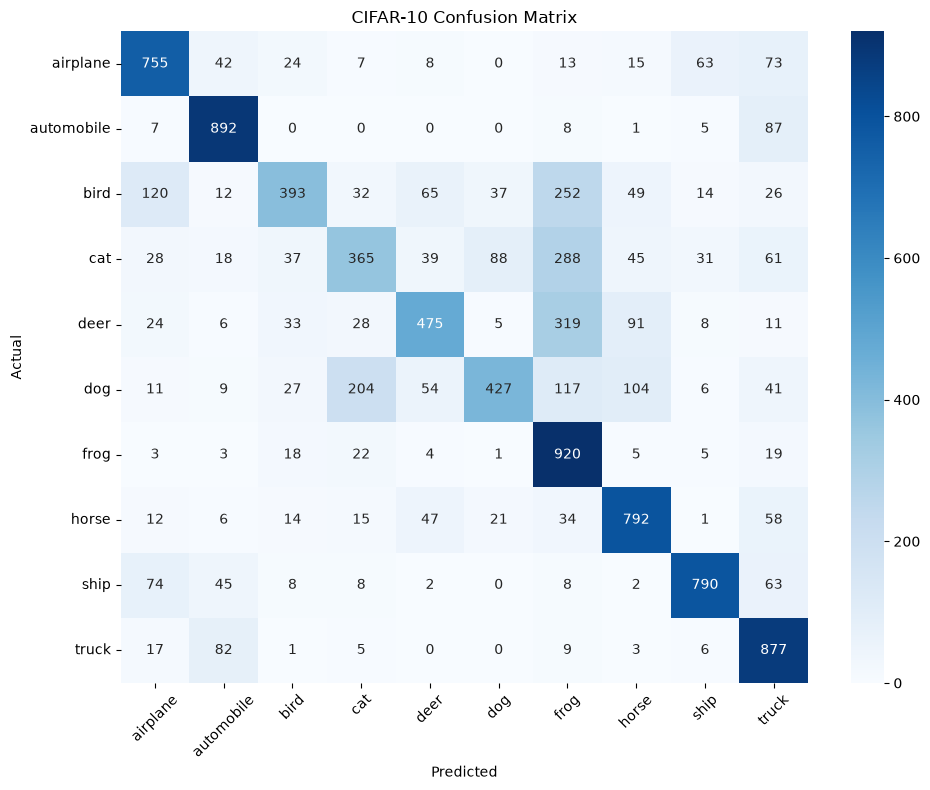

In [5]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('CIFAR-10 Confusion Matrix')
plt.xticks(rotation=45); plt.yticks(rotation=0); plt.tight_layout(); plt.show()


Use the confusion matrix to identify visually similar categories, such as cat/dog or automobile/truck.